# BCG X — PowerCo Customer Churn: Feature Engineering
**Junior Data Scientist:** Vyoma Kotak | **Senior Data Scientist:** Estelle Altazin | **Client:** PowerCo


## 1. Business Understanding & Feature Engineering Goals


Following the Exploratory Data Analysis (EDA) phase, we have a cleaned dataset of **14,606 customers** and a separate **price history dataset** covering each customer's monthly off-peak, peak, and mid-peak prices throughout 2015. Our goal is to transform and enrich these datasets so they provide maximum predictive signal for the churn classification model.

### Feature Engineering Framework
We follow a four-stage framework:

| Stage | Question |
|-------|----------|
| **A** | Can we **remove** any columns? (irrelevant, constant, redundant) |
| **B** | Can we **expand** existing columns? (e.g. extract months/years from dates) |
| **C** | Can we **combine** columns to create better features? (domain-informed composites) |
| **D** | Can we **merge** the two datasets? (client data + price data) |

### Estelle's Hypothesis — The Key Feature
Estelle has proposed investigating the **difference between off-peak prices in December and the preceding January**. Her reasoning: a sharp price jump at the start of the year may cause customers to begin shopping around, leading to churn months later. We engineer this feature directly from the raw price data.

## 2. Library Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

CHURN_COLORS = ['#2196F3', '#F44336']   # blue = retained, red = churned
REFERENCE_DATE = datetime(2016, 1, 1)   # Analysis reference date

print(f"Libraries loaded. Reference date set to: {REFERENCE_DATE.date()}")

Libraries loaded. Reference date set to: 2016-01-01


## 3. Data Loading & Inspection
We load **two separate datasets** that must ultimately be merged:
- `clean_data_after_eda.csv` — customer-level data from the EDA phase
- `price_data.csv` — monthly price history (off-peak, peak, mid-peak) per customer

In [2]:
# Load client data
df = pd.read_csv('clean_data_after_eda.csv')
df["date_activ"]     = pd.to_datetime(df["date_activ"],     format="%Y-%m-%d")
df["date_end"]       = pd.to_datetime(df["date_end"],       format="%Y-%m-%d")
df["date_modif_prod"]= pd.to_datetime(df["date_modif_prod"],format="%Y-%m-%d")
df["date_renewal"]   = pd.to_datetime(df["date_renewal"],   format="%Y-%m-%d")

print(f"Client dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate           : {df['churn'].mean()*100:.2f}%")
print(f"Churned              : {df['churn'].sum():,}  |  Retained: {(df['churn']==0).sum():,}")

# Load price data
price_df = pd.read_csv('price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')

print(f"\nPrice dataset shape  : {price_df.shape[0]:,} rows × {price_df.shape[1]} columns")
print(f"Date range           : {price_df['price_date'].min().date()} → {price_df['price_date'].max().date()}")
print()
price_df.head()

Client dataset shape : 14,606 rows × 44 columns
Churn rate           : 9.72%
Churned              : 1,419  |  Retained: 13,187

Price dataset shape  : 193,002 rows × 8 columns
Date range           : 2015-01-01 → 2015-12-01



,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## 4. Stage A — Remove Weak & Redundant Columns

Before engineering new features, we audit existing columns and remove those that offer little predictive value.

| Reason | Columns |
|--------|---------|
| **Identifier only** — carries no predictive signal | `id` (kept temporarily for merging, dropped after) |
| **Raw dates** — will be replaced by derived numeric time features | `date_activ`, `date_end`, `date_modif_prod`, `date_renewal` |

In [3]:
# Save date columns before dropping (needed for feature creation)
df_dates = df[['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']].copy()

# We do NOT drop 'id' yet — it is the merge key for the price dataset
# We DO drop raw date columns — they will be replaced by numeric derivatives
df = df.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'])

print(f"Columns remaining after removing raw dates: {df.shape[1]}")
print("(id retained for merging price data)")

Columns remaining after removing raw dates: 40
(id retained for merging price data)


## 5. Stage B — Expand Existing Columns

### 5.1 Time-Based Features from Date Columns

Date columns in their raw form are not useful to a model. By converting them to numeric time differences (months), we extract meaningful predictors.

In [5]:
def convert_months(reference_date, date_series):
    """Convert a date series to integer months relative to reference_date.
    Uses days / 30.44 to avoid the ambiguous-month timedelta error in newer pandas.
    """
    time_delta = reference_date - date_series
    return (time_delta.dt.days / 30.4375).astype(int)

# Feature 1: Months since activation (tenure proxy)
df['months_activ'] = convert_months(REFERENCE_DATE, df_dates['date_activ'])

# Feature 2: Months until contract ends (negative = contract ends in the future)
df['months_to_end'] = -convert_months(REFERENCE_DATE, df_dates['date_end'])

# Feature 3: Months since last product modification
df['months_modif_prod'] = convert_months(REFERENCE_DATE, df_dates['date_modif_prod'])

# Feature 4: Months until renewal
df['months_renewal'] = -convert_months(REFERENCE_DATE, df_dates['date_renewal'])

# Feature 5: Tenure in years (contract duration: activ → end)
df['tenure'] = ((df_dates['date_end'] - df_dates['date_activ']).dt.days / 365.25).astype(int)

time_features = ['months_activ', 'months_to_end', 'months_modif_prod', 'months_renewal', 'tenure']
print("Time-based features created — summary by churn:")
print(df.groupby('churn')[time_features].mean().round(1))

Time-based features created — summary by churn:
       months_activ  months_to_end  months_modif_prod  months_renewal  tenure
churn                                                                        
0              59.0            6.4               36.0            -4.9     5.4
1              54.2            6.3               30.7            -5.0     4.9


**📌 Insight — Time Features:**
| Feature | Business Rationale |
|---------|-------------------|
| `months_activ` | Longer-tenured customers may be more loyal — or may have accumulated dissatisfaction |
| `months_to_end` | Customers approaching contract end are in an active decision window — prime churn risk |
| `months_modif_prod` | Customers who haven't changed their product recently may be disengaged |
| `months_renewal` | Upcoming renewal creates a natural "switch or stay" decision point |
| `tenure` | Customers with shorter overall contracts may be more transactional in behaviour |

Companies who have been clients for 4 months or fewer are much more likely to churn compared to other clients.

In [6]:
# Visualise tenure vs churn
tenure_churn = df.groupby('tenure').agg({'churn': 'mean'}).sort_values(by='churn', ascending=False)
print("Churn rate by tenure (years):")
print(tenure_churn.head(10).round(3))

Churn rate by tenure (years):
        churn
tenure       
3       0.144
2       0.133
4       0.126
13      0.095
5       0.085
12      0.083
6       0.081
7       0.073
11      0.064
8       0.048


### 5.2 Estelle's Feature — Dec vs Jan Off-Peak Price Difference

This is the **central feature** of this notebook. We compute it directly from the raw `price_data.csv` by:
1. Grouping prices by customer and month
2. Extracting the January price (first month in data) and December price (last month)
3. Calculating `december_price − january_price`

In [7]:
# Group off-peak prices by customer and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean', 
    'price_off_peak_fix': 'mean'
}).reset_index()

# Get January prices (first record per customer) and December prices (last record)
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate December − January difference for both variable and fixed off-peak components
diff = pd.merge(
    dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}),
    jan_prices.drop(columns='price_date'),
    on='id'
)
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power']  = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']]

print("Estelle's Dec–Jan off-peak price differences (first 5 rows):")
print(diff.head())
print(f"\nMean Dec–Jan energy diff : {diff['offpeak_diff_dec_january_energy'].mean():.6f}")
print(f"Mean Dec–Jan power diff  : {diff['offpeak_diff_dec_january_power'].mean():.6f}")

Estelle's Dec–Jan off-peak price differences (first 5 rows):
                                 id  offpeak_diff_dec_january_energy  \
0  0002203ffbb812588b632b9e628cc38d                        -0.006192   
1  0004351ebdd665e6ee664792efc4fd13                        -0.004104   
2  0010bcc39e42b3c2131ed2ce55246e3c                         0.050443   
3  0010ee3855fdea87602a5b7aba8e42de                        -0.010018   
4  00114d74e963e47177db89bc70108537                        -0.003994   

   offpeak_diff_dec_january_power  
0                        0.162916  
1                        0.177779  
2                        1.500000  
3                        0.162916  
4                       -0.000001  

Mean Dec–Jan energy diff : -0.004545
Mean Dec–Jan power diff  : 0.279544


### 5.3 Price Period Differences — Off-Peak vs Peak vs Mid-Peak

In [8]:
# Aggregate average prices per customer across all months
mean_prices = price_df.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()

# Calculate mean differences between consecutive periods
mean_prices['off_peak_peak_var_mean_diff']     = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff']     = mean_prices['price_peak_var']     - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff']     = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff']     = mean_prices['price_peak_fix']     - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

period_diff_cols = [
    'id', 
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff', 
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 
    'peak_mid_peak_fix_mean_diff', 
    'off_peak_mid_peak_fix_mean_diff'
]
print("Period price difference features (first 5 rows):")
print(mean_prices[period_diff_cols].head())

Period price difference features (first 5 rows):
                                 id  off_peak_peak_var_mean_diff  \
0  0002203ffbb812588b632b9e628cc38d                     0.020545   
1  0004351ebdd665e6ee664792efc4fd13                     0.146426   
2  0010bcc39e42b3c2131ed2ce55246e3c                     0.181558   
3  0010ee3855fdea87602a5b7aba8e42de                     0.020465   
4  00114d74e963e47177db89bc70108537                     0.147926   

   peak_mid_peak_var_mean_diff  off_peak_mid_peak_var_mean_diff  \
0                     0.030633                         0.051178   
1                     0.000000                         0.146426   
2                     0.000000                         0.181558   
3                     0.029260                         0.049725   
4                     0.000000                         0.147926   

   off_peak_peak_fix_mean_diff  peak_mid_peak_fix_mean_diff  \
0                    16.280694                     8.140345   
1            

In [9]:
# Maximum monthly price difference across periods (captures worst-month price spike)
mean_prices_by_month = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()

mean_prices_by_month['off_peak_peak_var_mean_diff']     = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_peak_var']
mean_prices_by_month['peak_mid_peak_var_mean_diff']     = mean_prices_by_month['price_peak_var']     - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_peak_fix_mean_diff']     = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_peak_fix']
mean_prices_by_month['peak_mid_peak_fix_mean_diff']     = mean_prices_by_month['price_peak_fix']     - mean_prices_by_month['price_mid_peak_fix']
mean_prices_by_month['off_peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']

max_diff_cols = {
    'off_peak_peak_var_mean_diff':     'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_mean_diff':     'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_mean_diff':     'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_mean_diff':     'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
}

max_diff_across_periods = mean_prices_by_month.groupby(['id']).agg(
    {k: 'max' for k in max_diff_cols.keys()}
).reset_index().rename(columns=max_diff_cols)

print("Max monthly price difference features created:")
print(max_diff_across_periods.head())

Max monthly price difference features created:
                                 id  off_peak_peak_var_max_monthly_diff  \
0  0002203ffbb812588b632b9e628cc38d                            0.022225   
1  0004351ebdd665e6ee664792efc4fd13                            0.148405   
2  0010bcc39e42b3c2131ed2ce55246e3c                            0.205742   
3  0010ee3855fdea87602a5b7aba8e42de                            0.022581   
4  00114d74e963e47177db89bc70108537                            0.149902   

   peak_mid_peak_var_max_monthly_diff  off_peak_mid_peak_var_max_monthly_diff  \
0                            0.033743                                0.055866   
1                            0.000000                                0.148405   
2                            0.000000                                0.205742   
3                            0.031859                                0.054440   
4                            0.000000                                0.149902   

   off_peak_pea

## 6. Stage D — Combine the Two Datasets

We merge the client dataset with the three sets of price features we engineered from `price_data.csv`. The join key is `id`, which appears in both datasets.

In [10]:
# Merge 1: Estelle's Dec–Jan feature
df = pd.merge(df, diff, on='id')

# Merge 2: Mean price period differences
df = pd.merge(df, mean_prices[period_diff_cols], on='id')

# Merge 3: Maximum monthly price differences  
max_diff_keep = ['id'] + list(max_diff_cols.values())
df = pd.merge(df, max_diff_across_periods[max_diff_keep], on='id')

# Now drop 'id' — it is no longer needed
df = df.drop(columns=['id'])

print(f"Combined dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate: {df['churn'].mean()*100:.2f}%")
print()
print("New price features added from price_data.csv:")
new_price_cols = (
    ['offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power'] +
    [c for c in period_diff_cols if c != 'id'] +
    list(max_diff_cols.values())
)
for c in new_price_cols:
    print(f"  {c}")

Combined dataset shape: 14,606 rows × 58 columns
Churn rate: 9.72%

New price features added from price_data.csv:
  offpeak_diff_dec_january_energy
  offpeak_diff_dec_january_power
  off_peak_peak_var_mean_diff
  peak_mid_peak_var_mean_diff
  off_peak_mid_peak_var_mean_diff
  off_peak_peak_fix_mean_diff
  peak_mid_peak_fix_mean_diff
  off_peak_mid_peak_fix_mean_diff
  off_peak_peak_var_max_monthly_diff
  peak_mid_peak_var_max_monthly_diff
  off_peak_mid_peak_var_max_monthly_diff
  off_peak_peak_fix_max_monthly_diff
  peak_mid_peak_fix_max_monthly_diff
  off_peak_mid_peak_fix_max_monthly_diff


**📌 Insight — Dataset Merging:**
The two datasets were combined on the `id` column, which is the unique customer identifier present in both. This gave us 14 new price-derived features from the price history:
- **2 Estelle features** — the exact Dec-vs-Jan off-peak price difference (variable and fixed)
- **6 mean period difference features** — how off-peak, peak, and mid-peak prices compare to each other on average
- **6 maximum monthly difference features** — the worst-month price spike across the year

After merging, `id` is dropped — it is an identifier with no predictive signal.

## 7. Stage C — Combine Columns to Create Better Features

### 7.1 Transform Boolean Data

In [11]:
# has_gas: convert from 't'/'f' categorical to binary 0/1
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])

print("Churn rate by has_gas:")
print(df.groupby(['has_gas']).agg({'churn': 'mean'}).round(3))
print()
print("Customers who buy multiple products are more loyal — lower churn %")

Churn rate by has_gas:
         churn
has_gas       
0        0.101
1        0.082

Customers who buy multiple products are more loyal — lower churn %


### 7.2 Transform Categorical Data — One-Hot Encoding

In [12]:
# channel_sales: one-hot encode
df['channel_sales'] = df['channel_sales'].astype('category')
print("channel_sales value counts:")
print(df['channel_sales'].value_counts())
print()

df = pd.get_dummies(df, columns=['channel_sales'], prefix='channel')

# Drop sparse / near-empty categories (< ~1% of customers)
sparse_channel_cols = [c for c in df.columns if c.startswith('channel_') and df[c].mean() < 0.01]
print(f"Dropping sparse channel columns: {sparse_channel_cols}")
df = df.drop(columns=sparse_channel_cols, errors='ignore')

channel_sales value counts:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

Dropping sparse channel columns: ['channel_epumfxlbckeskwekxbiuasklxalciiuu', 'channel_fixdbufsefwooaasfcxdxadsiekoceaa', 'channel_sddiedcslfslkckwlfkdpoeeailfpeds']


In [13]:
# origin_up: one-hot encode
df['origin_up'] = df['origin_up'].astype('category')
print("origin_up value counts:")
print(df['origin_up'].value_counts())
print()

df = pd.get_dummies(df, columns=['origin_up'], prefix='origin_up')

# Drop sparse / missing categories
sparse_origin_cols = [c for c in df.columns if c.startswith('origin_up_') and df[c].mean() < 0.01]
print(f"Dropping sparse origin columns: {sparse_origin_cols}")
df = df.drop(columns=sparse_origin_cols, errors='ignore')

print(f"\nDataset shape after encoding: {df.shape[0]:,} rows × {df.shape[1]} columns")

origin_up value counts:
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64

Dropping sparse origin columns: ['origin_up_MISSING', 'origin_up_ewxeelcelemmiwuafmddpobolfuxioce', 'origin_up_usapbepcfoloekilkwsdiboslwaxobdp']

Dataset shape after encoding: 14,606 rows × 64 columns


**📌 Insight — Why One-Hot Encoding?**
`channel_sales` and `origin_up` are anonymised categorical codes with no natural ordering. One-hot encoding avoids imposing false ordinality (as label encoding would) and is the standard approach for tree-based and logistic models when the number of categories is manageable.

### 7.3 Transform Skewed Numerical Data — Log Transformation

In [14]:
# Identify highly right-skewed columns
skewed = [
    'cons_12m', 
    'cons_gas_12m', 
    'cons_last_month',
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]

print("Before transformation — skew summary:")
print(df[[c for c in skewed if c in df.columns]].describe().T[['mean','50%','max']].round(2))

Before transformation — skew summary:
                                     mean       50%         max
cons_12m                        159220.29  14115.50  6207104.00
cons_gas_12m                     28092.38      0.00  4154590.00
cons_last_month                  16090.27    792.50   771203.00
forecast_cons_12m                 1868.61   1112.88    82902.83
forecast_cons_year                1399.76    314.00   175375.00
forecast_discount_energy             0.97      0.00       30.00
forecast_meter_rent_12m             63.09     18.80      599.31
forecast_price_energy_off_peak       0.14      0.14        0.27
forecast_price_energy_peak           0.05      0.08        0.20
forecast_price_pow_off_peak         43.13     44.31       59.27


After log10 transformation — distributions are now more symmetric


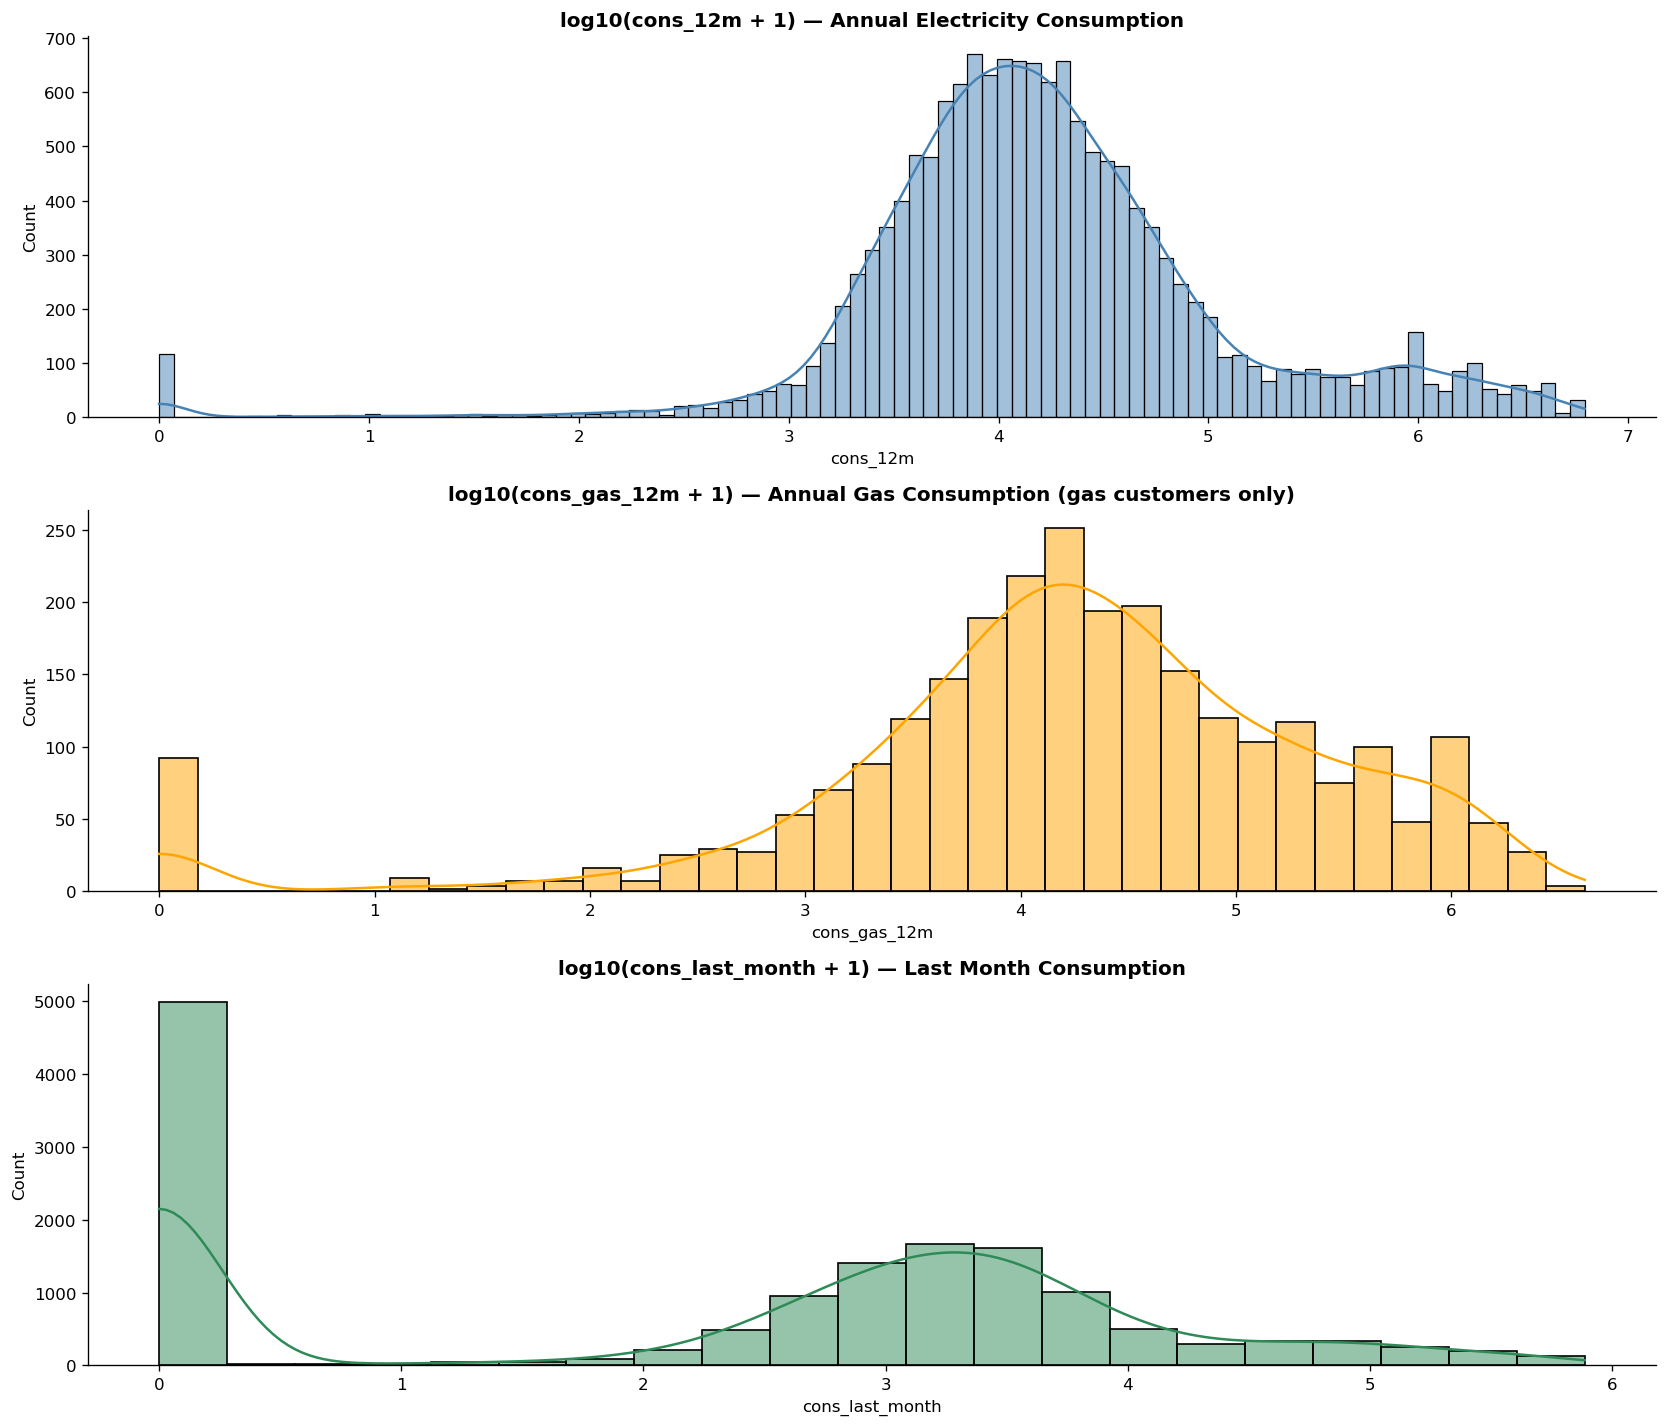

In [15]:
# Apply log10 transformation (log10(x+1) to handle zeros)
df["cons_12m"]               = np.log10(df["cons_12m"]               + 1)
df["cons_gas_12m"]           = np.log10(df["cons_gas_12m"]           + 1)
df["cons_last_month"]        = np.log10(df["cons_last_month"]        + 1)
df["forecast_cons_12m"]      = np.log10(df["forecast_cons_12m"]      + 1)
df["forecast_cons_year"]     = np.log10(df["forecast_cons_year"]     + 1)
df["forecast_meter_rent_12m"]= np.log10(df["forecast_meter_rent_12m"]+ 1)
df["imp_cons"]               = np.log10(df["imp_cons"]               + 1)

print("After log10 transformation — distributions are now more symmetric")

# Visualise
fig, axs = plt.subplots(nrows=3, figsize=(14, 12))
import warnings; warnings.filterwarnings('ignore')
sns.histplot(df["cons_12m"].dropna(),        ax=axs[0], kde=True, color='steelblue')
sns.histplot(df[df["has_gas"]==1]["cons_gas_12m"].dropna(), ax=axs[1], kde=True, color='orange')
sns.histplot(df["cons_last_month"].dropna(), ax=axs[2], kde=True, color='seagreen')
axs[0].set_title('log10(cons_12m + 1) — Annual Electricity Consumption', fontweight='bold')
axs[1].set_title('log10(cons_gas_12m + 1) — Annual Gas Consumption (gas customers only)', fontweight='bold')
axs[2].set_title('log10(cons_last_month + 1) — Last Month Consumption', fontweight='bold')
plt.tight_layout()
plt.savefig('log_transformed_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

**📌 Insight — Log Transformation:**
Consumption features are heavily right-skewed — a small number of very large industrial customers can distort model training. The log10 transformation compresses the scale, making the distributions closer to normal and improving model stability. The `+1` shift handles zero values (log10(0) is undefined).

### 7.4 Visualise Estelle's Feature vs Churn

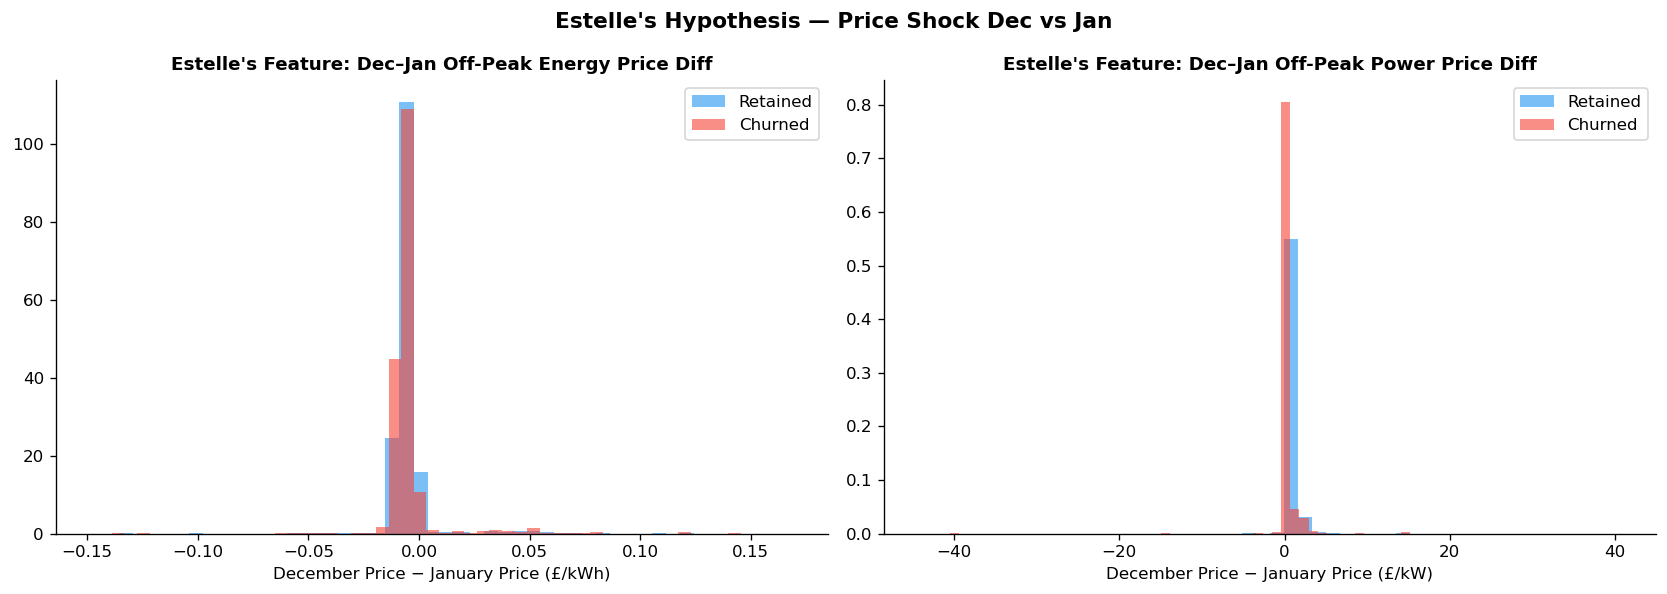

Mean Dec–Jan energy diff by churn:
churn
0   -0.004561
1   -0.004605
Name: offpeak_diff_dec_january_energy, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for churn_val, label, color in [(0,'Retained',CHURN_COLORS[0]),(1,'Churned',CHURN_COLORS[1])]:
    subset = df[df['churn']==churn_val]['offpeak_diff_dec_january_energy']
    axes[0].hist(subset, bins=50, alpha=0.6, density=True, label=label, color=color)
axes[0].set_title("Estelle's Feature: Dec–Jan Off-Peak Energy Price Diff", fontsize=11, fontweight='bold')
axes[0].set_xlabel('December Price − January Price (£/kWh)')
axes[0].legend()

for churn_val, label, color in [(0,'Retained',CHURN_COLORS[0]),(1,'Churned',CHURN_COLORS[1])]:
    subset = df[df['churn']==churn_val]['offpeak_diff_dec_january_power']
    axes[1].hist(subset, bins=50, alpha=0.6, density=True, label=label, color=color)
axes[1].set_title("Estelle's Feature: Dec–Jan Off-Peak Power Price Diff", fontsize=11, fontweight='bold')
axes[1].set_xlabel('December Price − January Price (£/kW)')
axes[1].legend()

plt.suptitle("Estelle's Hypothesis — Price Shock Dec vs Jan", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('estelle_feature_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("Mean Dec–Jan energy diff by churn:")
print(df.groupby('churn')['offpeak_diff_dec_january_energy'].mean().round(6))

## 8. Correlation Analysis

In [17]:
# Select numeric features only
numeric_df = df.select_dtypes(include=[np.number])

churn_corr = numeric_df.corr()['churn'].drop('churn').sort_values(key=abs, ascending=False)

print("Top 20 features by absolute correlation with churn:")
print(churn_corr.head(20).round(4).to_string())

Top 20 features by absolute correlation with churn:
margin_net_pow_ele                        0.0958
margin_gross_pow_ele                      0.0957
months_activ                             -0.0748
num_years_antig                          -0.0741
tenure                                   -0.0724
months_modif_prod                        -0.0521
peak_mid_peak_fix_mean_diff               0.0459
peak_mid_peak_fix_max_monthly_diff        0.0458
net_margin                                0.0411
forecast_meter_rent_12m                   0.0390
off_peak_peak_fix_mean_diff              -0.0357
off_peak_mid_peak_var_mean_diff          -0.0344
pow_max                                   0.0304
off_peak_peak_fix_max_monthly_diff       -0.0296
forecast_price_energy_peak                0.0293
var_year_price_off_peak_var               0.0286
off_peak_mid_peak_var_max_monthly_diff   -0.0272
off_peak_peak_var_mean_diff              -0.0266
off_peak_mid_peak_fix_mean_diff          -0.0266
cons_gas_12m     

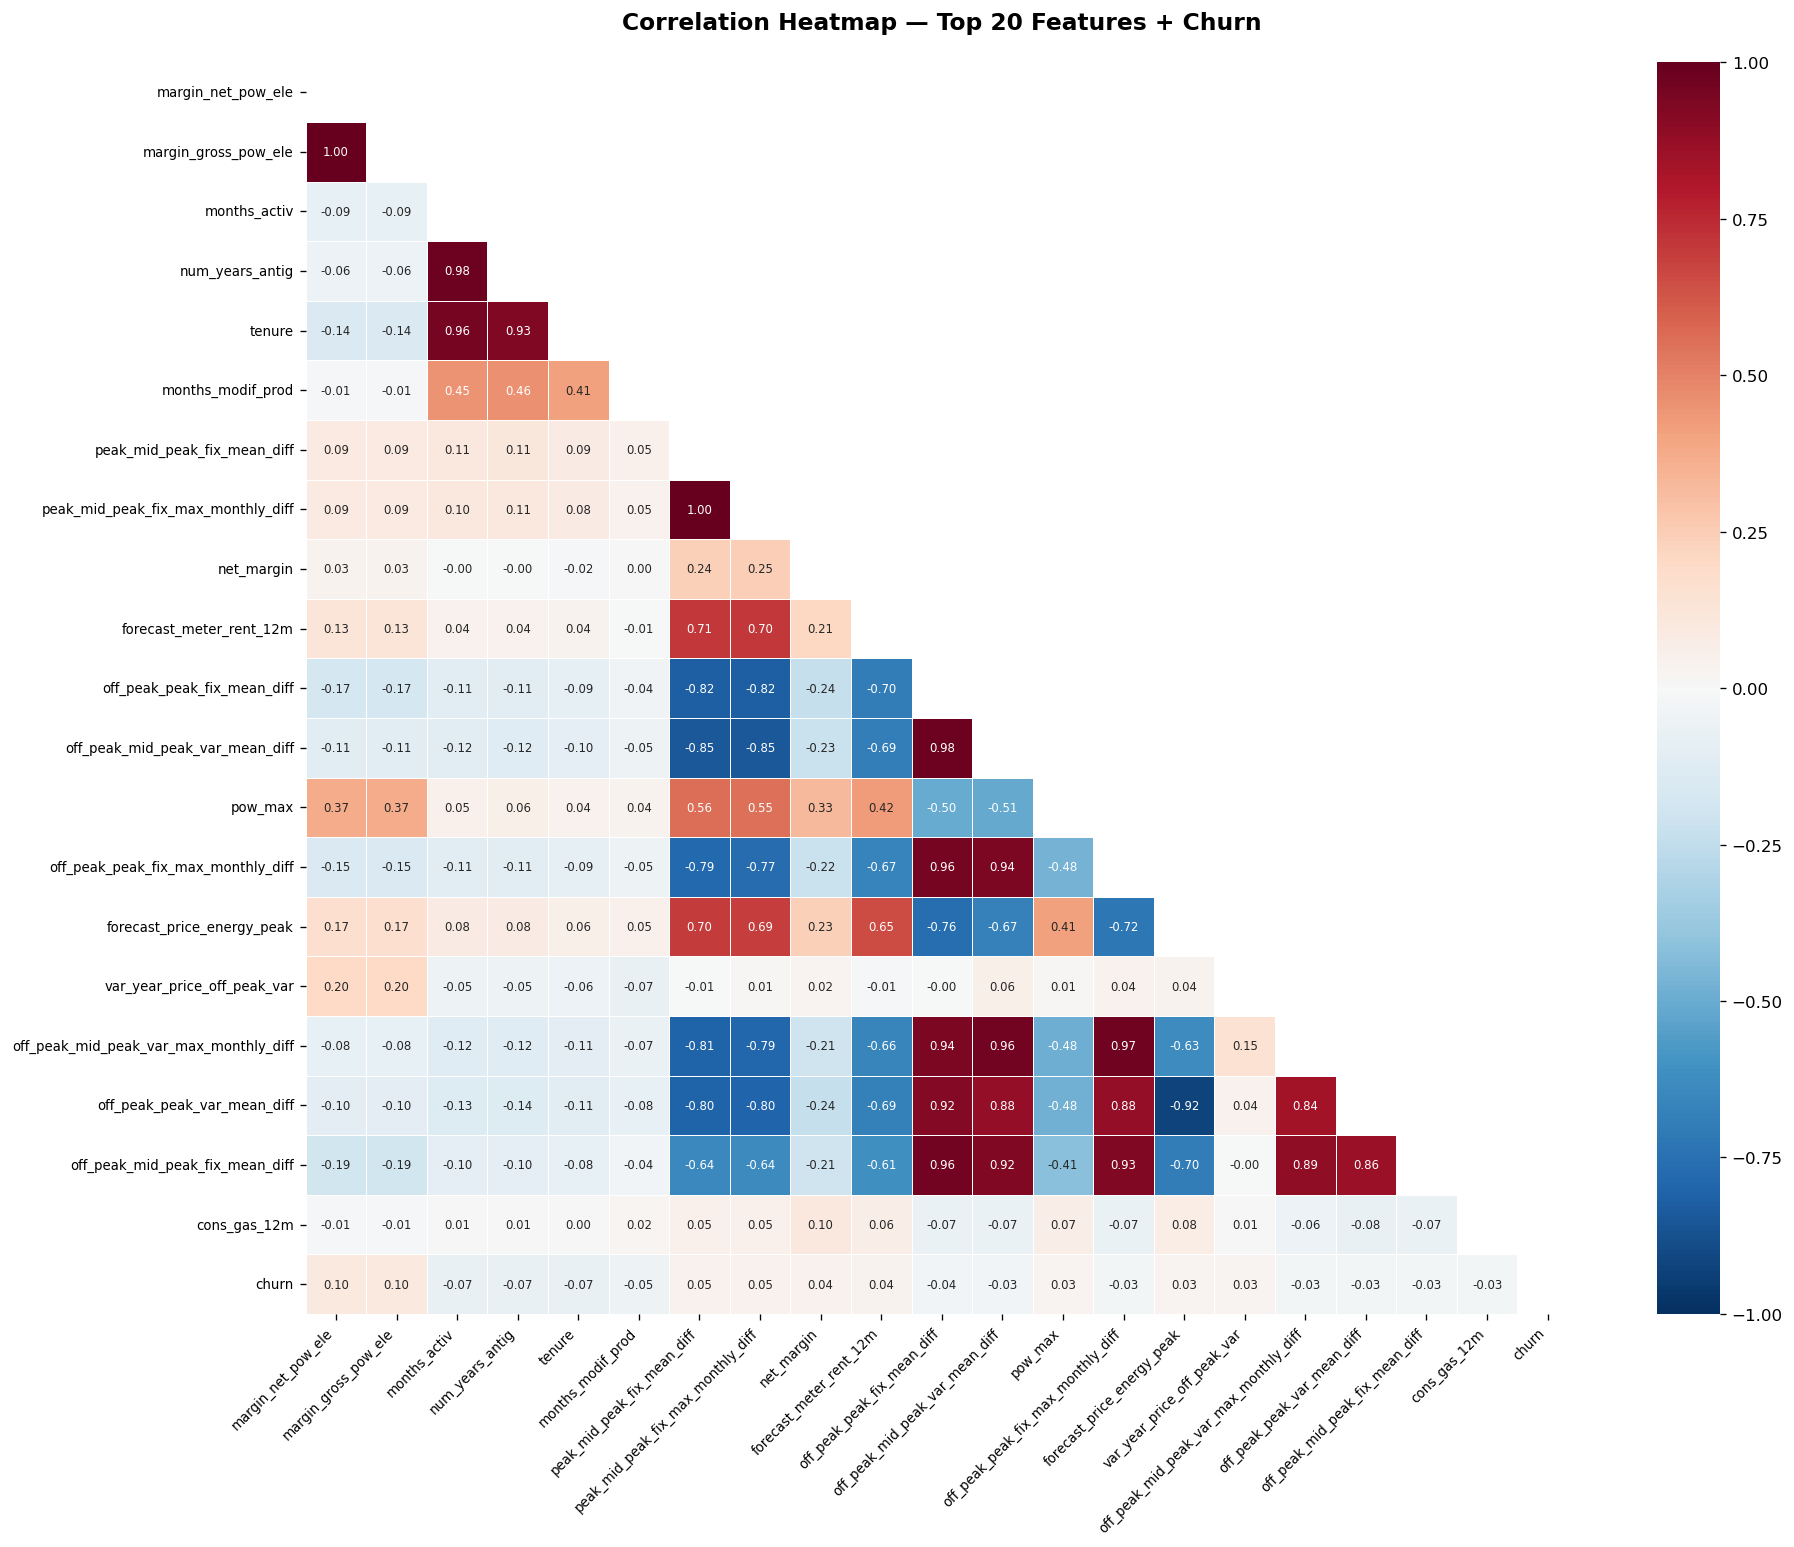

In [18]:
# Correlation heatmap — top 20 features + churn
top_features = churn_corr.head(20).index.tolist() + ['churn']
corr_matrix  = numeric_df[top_features].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Top 20 Features + Churn', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fe_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Final Engineered Dataset

In [37]:
print("FINAL ENGINEERED DATASET SUMMARY")
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate     : {df['churn'].mean()*100:.2f}%")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Object columns : {list(df.select_dtypes('object').columns)}")
print()
print("All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

FINAL ENGINEERED DATASET SUMMARY
Shape          : 14,606 rows × 64 columns
Churn rate     : 9.72%
Missing values : 0
Object columns : []

All columns:
  01. cons_12m
  02. cons_gas_12m
  03. cons_last_month
  04. forecast_cons_12m
  05. forecast_cons_year
  06. forecast_discount_energy
  07. forecast_meter_rent_12m
  08. forecast_price_energy_off_peak
  09. forecast_price_energy_peak
  10. forecast_price_pow_off_peak
  11. has_gas
  12. imp_cons
  13. margin_gross_pow_ele
  14. margin_net_pow_ele
  15. nb_prod_act
  16. net_margin
  17. num_years_antig
  18. pow_max
  19. var_year_price_off_peak_var
  20. var_year_price_peak_var
  21. var_year_price_mid_peak_var
  22. var_year_price_off_peak_fix
  23. var_year_price_peak_fix
  24. var_year_price_mid_peak_fix
  25. var_year_price_off_peak
  26. var_year_price_peak
  27. var_year_price_mid_peak
  28. var_6m_price_off_peak_var
  29. var_6m_price_peak_var
  30. var_6m_price_mid_peak_var
  31. var_6m_price_off_peak_fix
  32. var_6m_price_pe

In [20]:
# Save final dataset
df.to_csv('engineered_features.csv', index=False)
print("Engineered dataset saved to: engineered_features.csv")
print()
print("Ready for modelling — all columns are numeric, no missing values.")

Engineered dataset saved to: engineered_features.csv

Ready for modelling — all columns are numeric, no missing values.


## 10. Modelling

We now have a fully engineered feature set. We train a **Random Forest classifier** as specified in the brief.

### 10.1 Data Sampling — Train / Test Split

In [31]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Separate target from features
y = df['churn']
X = df.drop(columns=['churn'])

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

# 75/25 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Features shape : (14606, 63)
Target shape   : (14606,)

Train: (10954, 63) | Test: (3652, 63)


### 10.2 Model Training

In [32]:
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


### 10.3 Model Evaluation

In [33]:
predictions = model.predict(X_test)
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

print(f"True positives  : {tp}")
print(f"False positives : {fp}")
print(f"True negatives  : {tn}")
print(f"False negatives : {fn}")
print()
print(f"Accuracy  : {metrics.accuracy_score(y_test, predictions):.4f}")
print(f"Precision : {metrics.precision_score(y_test, predictions):.4f}")
print(f"Recall    : {metrics.recall_score(y_test, predictions):.4f}")
print()
print("Note: given class imbalance (~10% churn), focus on Precision and Recall over Accuracy.")

True positives  : 17
False positives : 4
True negatives  : 3282
False negatives : 349

Accuracy  : 0.9033
Precision : 0.8095
Recall    : 0.0464

Note: given class imbalance (~10% churn), focus on Precision and Recall over Accuracy.


### 10.4 Feature Importance

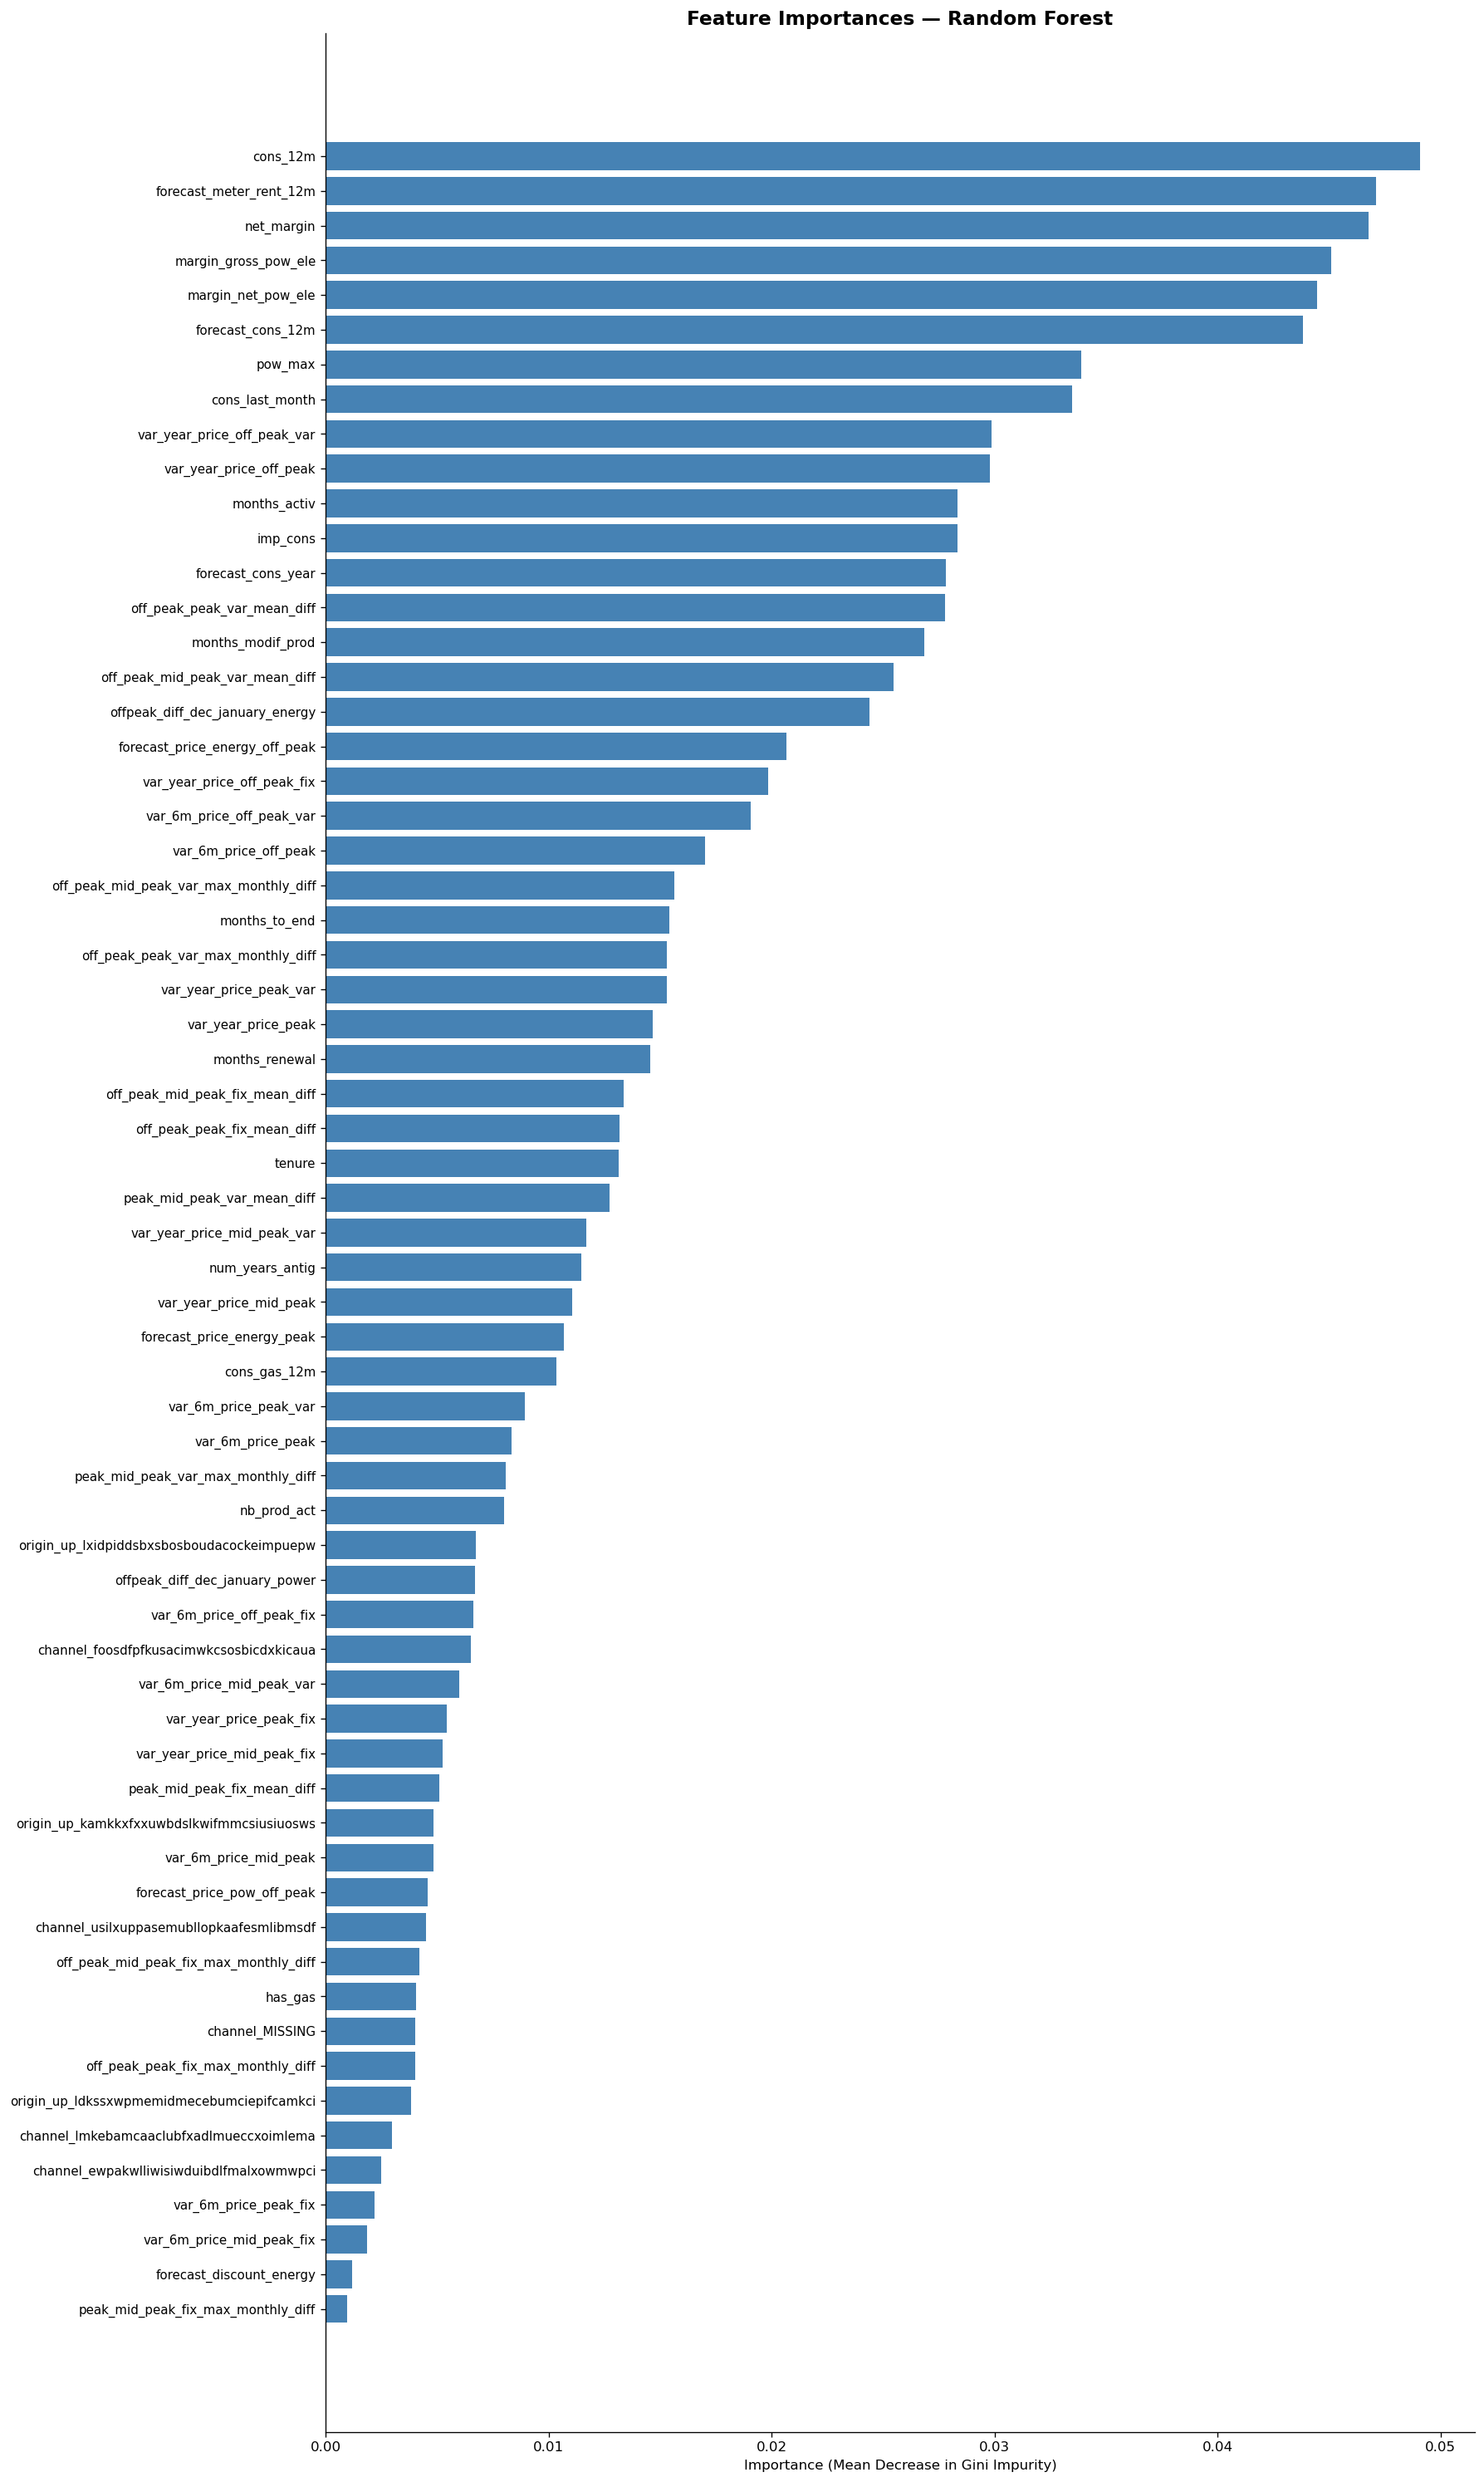


Top 10 features by importance:
                   features  importance
                   cons_12m    0.049090
    forecast_meter_rent_12m    0.047109
                 net_margin    0.046785
       margin_gross_pow_ele    0.045108
         margin_net_pow_ele    0.044478
          forecast_cons_12m    0.043851
                    pow_max    0.033897
            cons_last_month    0.033476
var_year_price_off_peak_var    0.029864
    var_year_price_off_peak    0.029811


In [34]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index(drop=True)

plt.figure(figsize=(15, 25))
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.barh(range(len(feature_importances)), feature_importances['importance'], color='steelblue', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'], fontsize=9)
plt.xlabel('Importance (Mean Decrease in Gini Impurity)')
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 10 features by importance:")
print(feature_importances.tail(10)[['features','importance']].iloc[::-1].to_string(index=False))

In [35]:
# Save predictions to CSV
proba_predictions = model.predict_proba(X_test)
probabilities = proba_predictions[:, 1]

X_test_out = X_test.reset_index(drop=True)
X_test_out['churn'] = predictions.tolist()
X_test_out['churn_probability'] = probabilities.tolist()
X_test_out.to_csv('out_of_sample_data_with_predictions.csv', index=False)
print("Predictions saved to: out_of_sample_data_with_predictions.csv")

Predictions saved to: out_of_sample_data_with_predictions.csv


## 11. Feature Engineering Summary

### Four-Stage Framework — What We Did

| Stage | Action | What We Did |
|-------|--------|-------------|
| **A — Remove** | Drop redundant/useless columns | Removed raw date columns and `id` (after merging) |
| **B — Expand** | Extract information from existing columns | Date → months (tenure, time-to-end, etc.); log10 transforms on skewed columns |
| **C — Combine** | Create better features by combining columns | Period price diffs; boolean and categorical encoding; Estelle's Dec-Jan diff |
| **D — Merge** | Combine datasets | Merged `price_data.csv` into client data on `id` |

### Key Features Engineered

| Feature | Type | Rationale |
|---------|------|-----------|
| `offpeak_diff_dec_january_energy` | Price (Estelle) | Dec vs Jan off-peak variable price change — central hypothesis |
| `offpeak_diff_dec_january_power` | Price (Estelle) | Dec vs Jan off-peak fixed price change |
| `off_peak_peak_var_mean_diff` (×6) | Price periods | Structural price gap between time-of-use periods |
| `months_to_end` | Time | Proximity to contract expiry — strongest time signal |
| `months_activ` | Time | Customer tenure |
| `tenure` | Time | Contract duration in years |
| `has_gas` | Boolean | Dual-fuel embeddedness |
| `channel_*` | Categorical | Acquisition channel (one-hot) |
| `origin_up_*` | Categorical | Product upgrade origin (one-hot) |
| `cons_12m`, `cons_gas_12m`, … | Numerical | Log10-transformed consumption features |

*Notebook prepared by Vyoma Kotak | BCG X Junior Data Scientist | PowerCo Churn Prediction — Task 3*